# Problem Statment:

Description: Banks earn a major revenue from lending loans. But it is often associated with risk. The borrower's may default on the loan. To mitigate this issue, the banks have decided to use Machine Learning to overcome this issue. They have collected past data on the loan borrowers & would like you to develop a strong ML Model to classify if any new borrower is likely to default or not.

The dataset is enormous & consists of multiple deteministic factors like borrowe's income, gender, loan pupose etc. The dataset is subject to strong multicollinearity & empty values. Can you overcome these factors & build a strong classifier to predict defaulters?

Objective: Understand the Dataset & cleanup (if required). Build classification model to predict weather the loan borrower will default or not. Also fine-tune the hyperparameters & compare the evaluation metrics of vaious classification algorithms.

In [ ]:
#Load the necessary python libraries
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,accuracy_score,roc_auc_score,roc_curve
from sklearn.metrics import confusion_matrix,auc,r2_score,f1_score
import datetime
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns


# Load the data

In [ ]:
#load the data and First look for data
df = pd.read_csv('/content/Loan_Default.csv')


In [ ]:
df.shape

(148670, 34)

# Features
* ID = Customer ID of Applicant
* year = Year of Application
* loan limit = maximum avaliable amount of the loan allowed to be taken
* Gender = sex type
* approv_in_adv = Is loan pre-approved or not
* loan_type = Type of loan
* loan_purpose = the reason you want to borrow money
* Credit_Worthiness = is how a lender determines that you will default on your debt obligations, or how worthy you are to receive new credit.
* open_credit = is a pre-approved loan between a lender and a borrower. It allows the borrower to make repeated withdrawals up to a certain limit.
* business_or_commercial = Usage type of the loan amount
* loan_amount = The exact loan amount
* rate_of_interest = is the amount a lender charges a borrower and is a percentage of the principal—the amount loaned.
* Interest_rate_spread = the difference between the interest rate a financial institution pays to depositors and the interest rate it receives from loans
* Upfront_charges = Fee paid to a lender by a borrower as consideration for making a new loan
* term = the loan's repayment period
* Neg_ammortization = refers to a situation when a loan borrower makes a payment less than the standard installment set by the bank.
* interest_only = amount of interest only without principles
* lump_sum_payment = is an amount of money that is paid in one single payment rather than in installments.
* property_value = the present worth of future benefits arising from the ownership of the property
* construction_type = Collateral construction type
* occupancy_type = classifications refer to categorizing structures based on their usage
* Secured_by = Type of Collatoral
* total_units = number of unites
* income = refers to the amount of money, property, and other transfers of value received over a set period of time
* credit_type = type of credit
* co-applicant_credit_type = is an additional person involved in the loan application process. Both applicant and co-applicant apply and sign for the loan
* age = applicant's age
* submission_of_application = Ensure the application is complete or not
* LTV = life-time value (LTV) is a prognostication of the net profit
* Region = applicant's place
* Security_Type = Type of Collatoral
* status = Loan status (Approved/Declined)
* dtir1 = debt-to-income ratio

# looking for More information of our data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

in our data some features are in int variables and some are catagorical variables

In [ ]:
#checking shape of our dataset
df.shape

(148670, 34)

We have 34 features of total 148670 ids/rows.

In [ ]:
#checking all features names
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [ ]:
df.head(5)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [ ]:
df["open_credit"].value_counts()

,count
open_credit,
nopc,148114
opc,556


In [ ]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [ ]:
df['Status'].value_counts()

,count
Status,
0,112031
1,36639


loan defaulted : 1 = 36639
and not defaulted : 0 =   112031

In [ ]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#checking null values
df.isna().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


Thera are null values,which must be filled

# Some Characteristics of data & Visualization

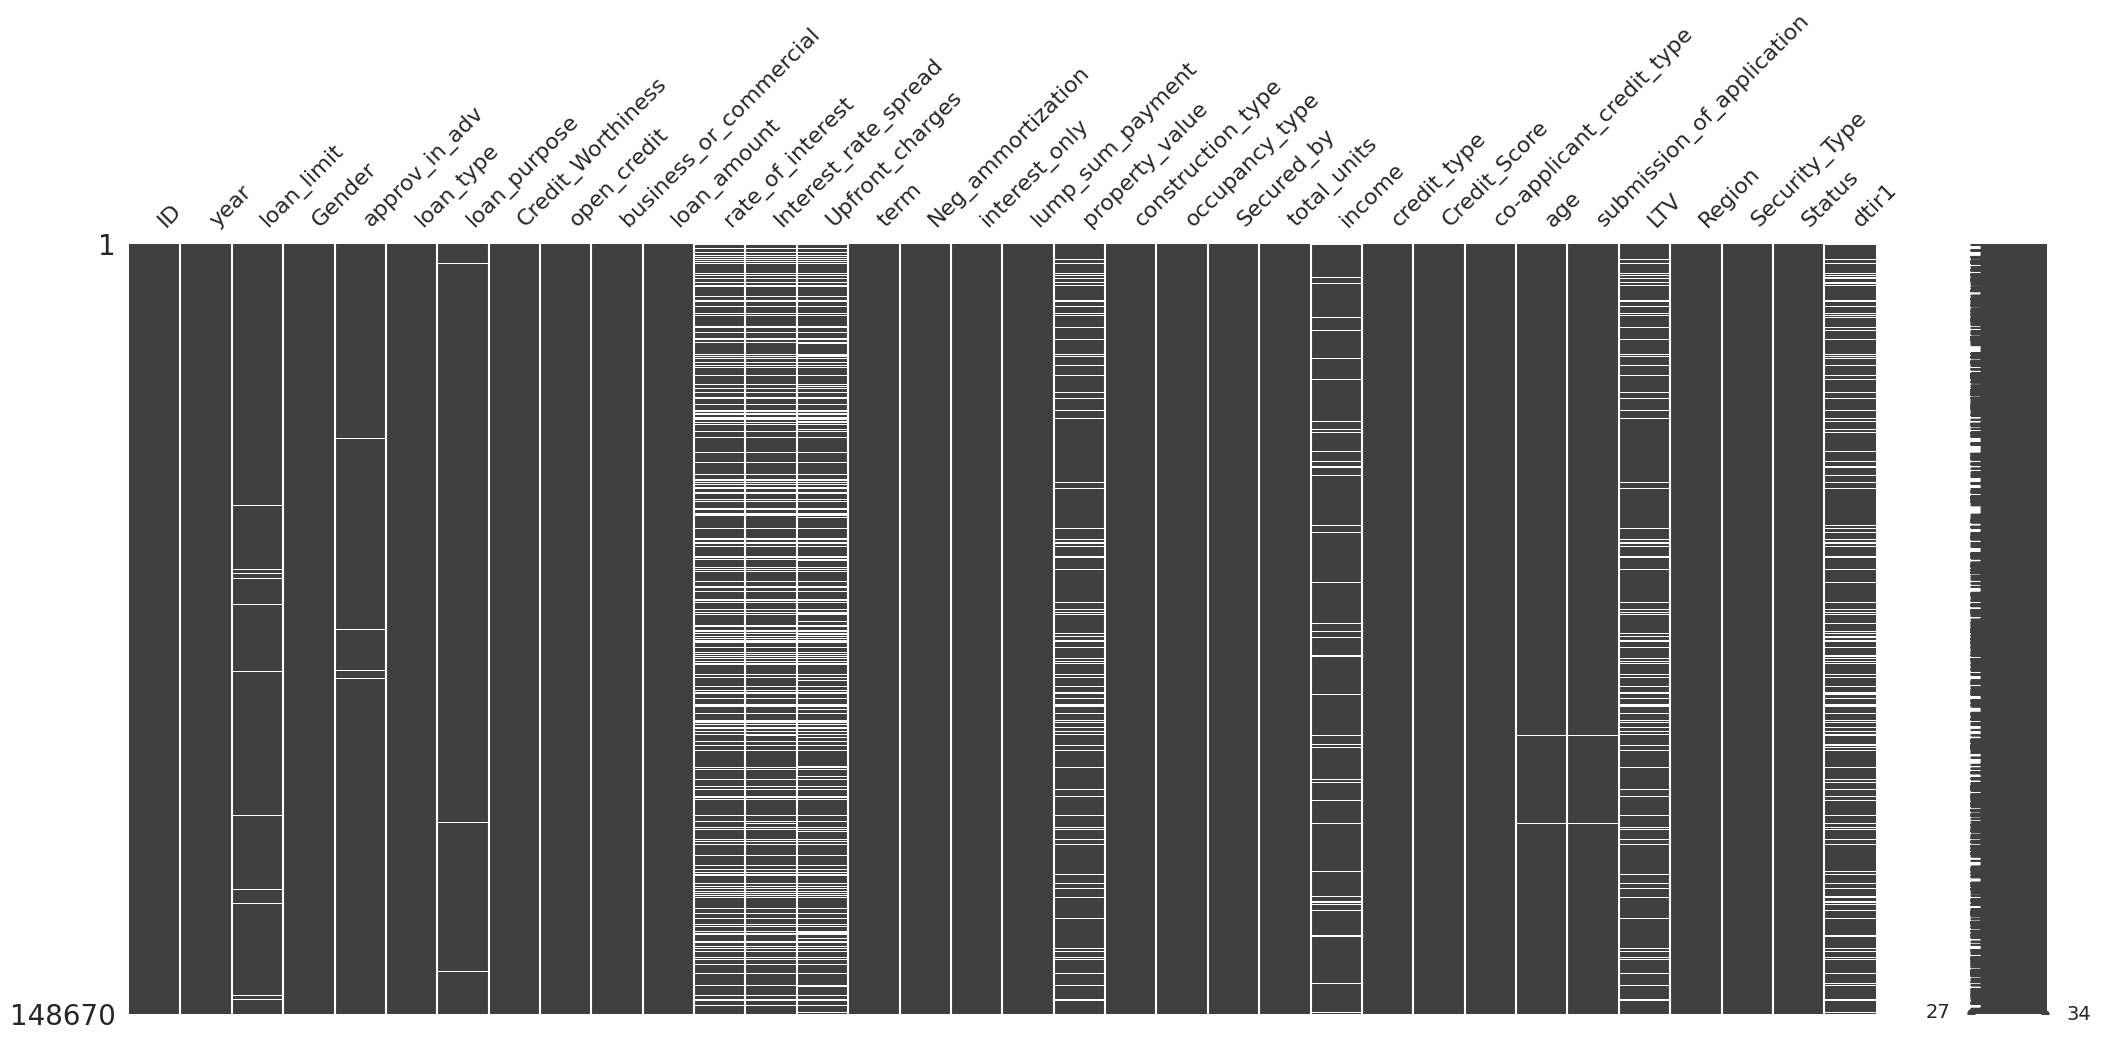

In [ ]:
#null values distribution
msno.matrix(df)
plt.show()

# Checking if the Loan defaulter is dependent on Gender

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,42346
Joint,41399
Sex Not Available,37659
Female,27266


In [ ]:
pd.crosstab(
    df['Gender'],
    df['Status'],
    normalize='index'
) * 100

Status,0,1
Gender,,
Female,74.884472,25.115528
Joint,80.837701,19.162299
Male,73.808624,26.191376
Sex Not Available,71.409225,28.590775


<Axes: xlabel='Gender', ylabel='count'>

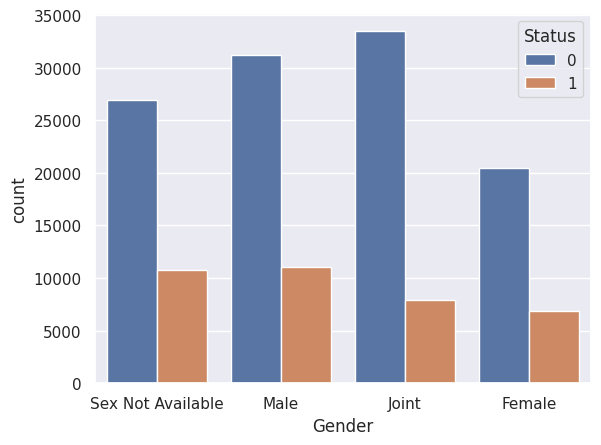

In [ ]:
sns.countplot(
    data=df,
    x='Gender',
    hue='Status'
)

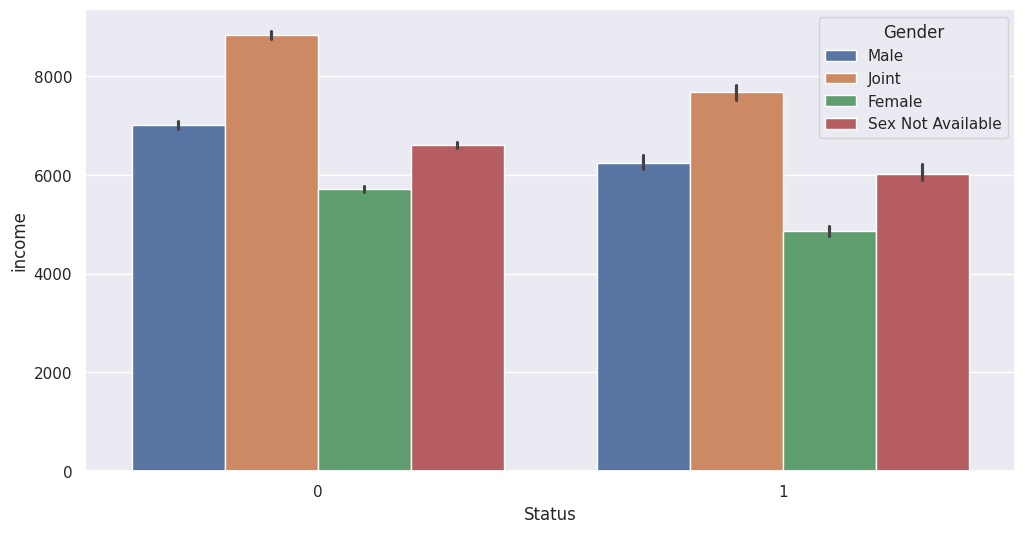

In [ ]:
fig,ax=plt.subplots()
sns.barplot(data=df,x='Status',y='income',hue='Gender')
fig.set_size_inches([12,6])
plt.show()

# How Loan defaulter is related to Credit score and Loan Amount

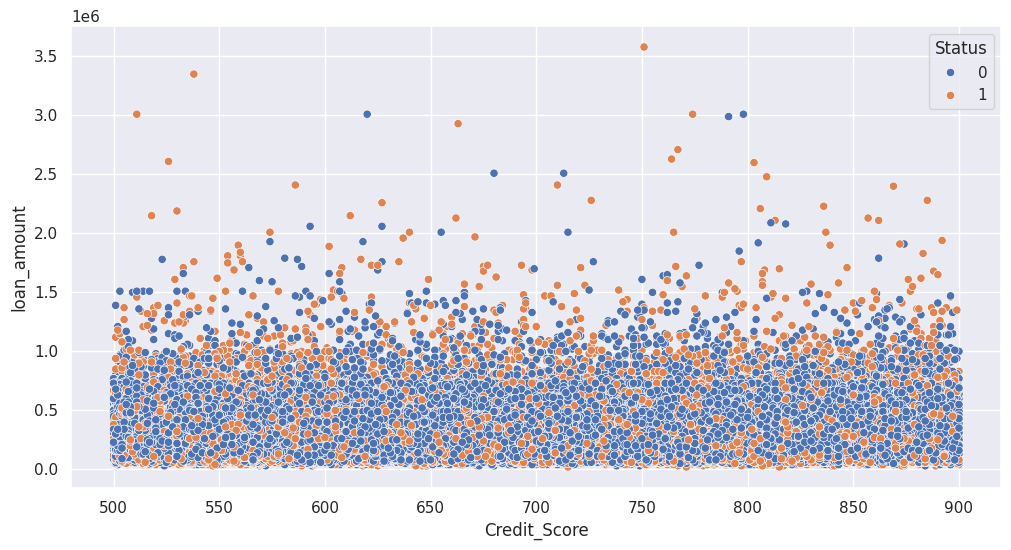

In [ ]:
fig,ax=plt.subplots()
sns.scatterplot(x='Credit_Score',y='loan_amount',data=df,hue='Status')
fig.set_size_inches([12,6])
plt.show()

# Let plot Pie and count plot

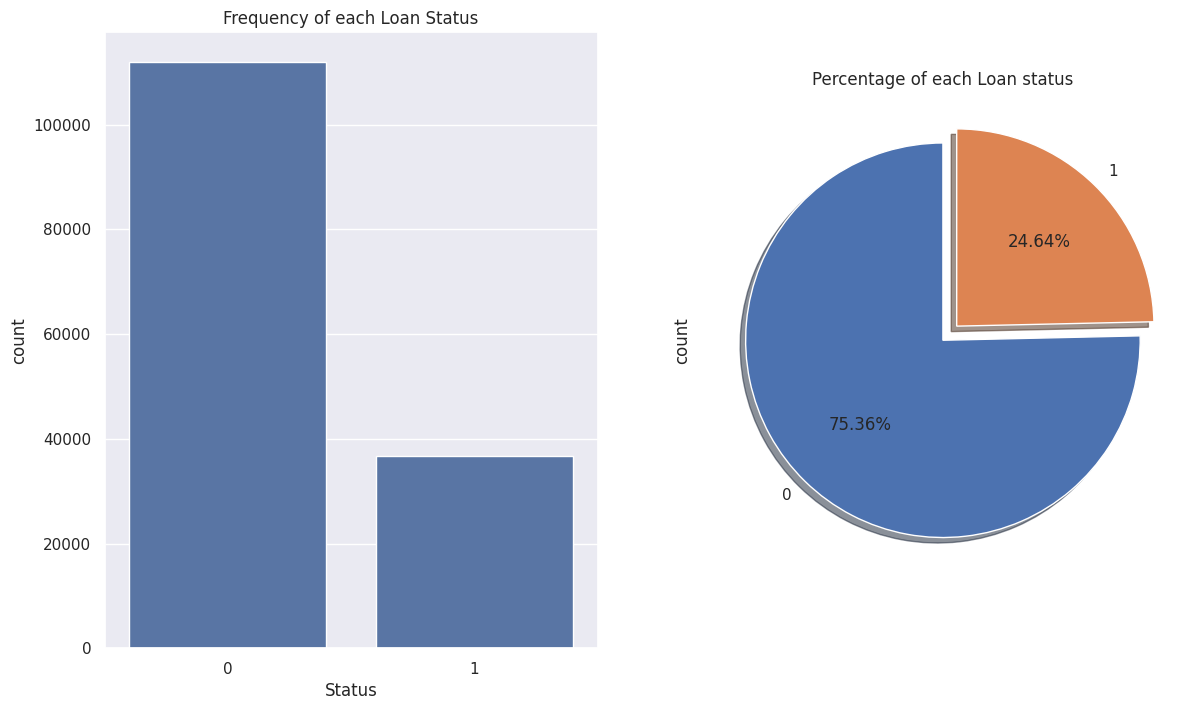

In [ ]:
sns.set_theme()
fig, axs = plt.subplots(1,2,figsize=(14,8))
sns.countplot(x='Status',data=df,ax=axs[0])
axs[0].set_title("Frequency of each Loan Status")
df.Status.value_counts().plot(x=None,y=None, kind='pie', ax=axs[1],shadow =True,explode = (0, 0.1,),autopct='%1.2f%%',startangle=90 )
axs[1].set_title("Percentage of each Loan status")
plt.show()

This clearly is a case of an imbalanced class problem where the value of class is far less than the other. There are cost function based approaches and sampling based approaches for handling this kind of problem which we will use later so that our model doesn't exhibit high bias while trying to predict if a loan will default or not.

A common thing to predict in datasets like these are if a new loan will get default or not. I'll be keeping loans with default status as my target variable.

Here, We have finalize loan status as our target variable which has now 24 % are defaulters for the loan payment.

<Axes: xlabel='loan_type', ylabel='count'>

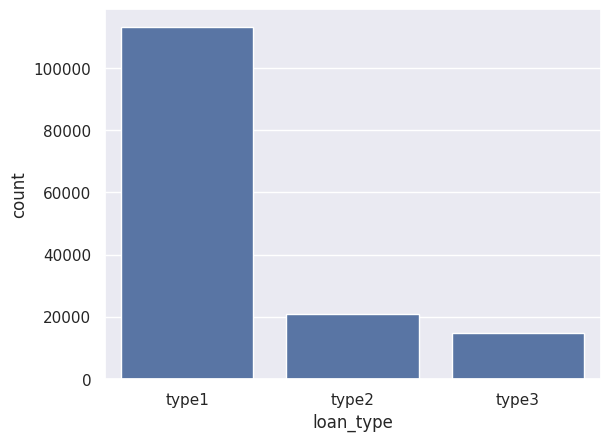

In [ ]:
sns.countplot(data=df , x='loan_type')

<Axes: xlabel='Status', ylabel='count'>

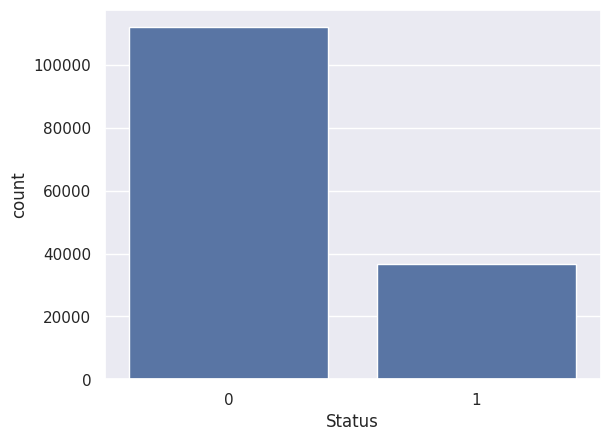

In [ ]:
sns.countplot(data=df , x='Status')

<Axes: xlabel='age', ylabel='count'>

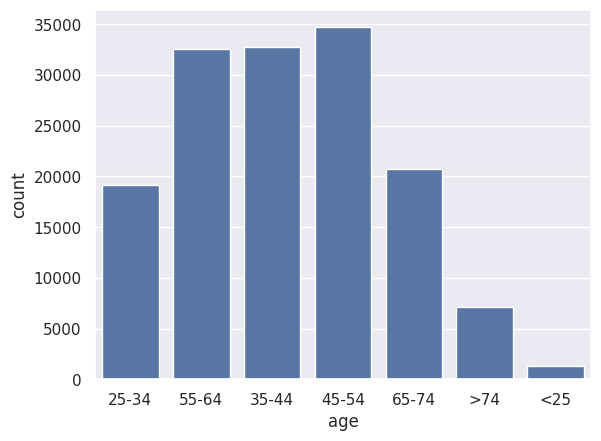

In [ ]:
sns.countplot(data=df , x='age')

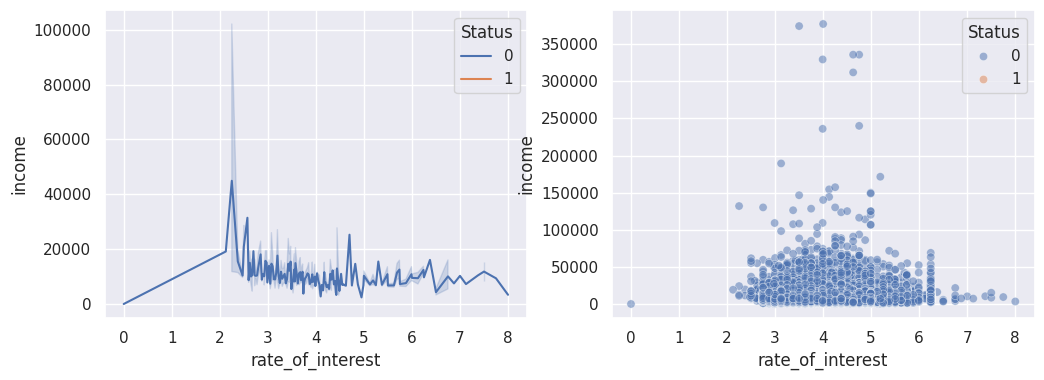

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(12,4))

sns.lineplot(data=df, x="rate_of_interest", y="income", hue="Status",ax = axs[0])
sns.scatterplot(
    data=df,
    x='rate_of_interest',
    y='income',
    hue='Status',
    alpha=0.5,ax = axs[1]
)

plt.show()

Most observations have rate_of_interest roughly between 2.5 and 6.5.

Most incomes are concentrated below about ₹50,000.

There are some very large income outliers.

There is no obvious strong linear relationship between rate_of_interest and income.

The points are widely scattered, so we shouldn't conclude that higher interest rates are associated with higher income.

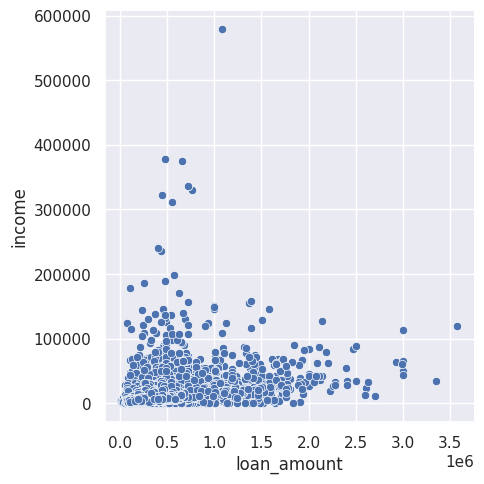

In [ ]:
sns.relplot(x ="loan_amount", y ="income",data = df)

<Figure size 1500x1500 with 0 Axes>

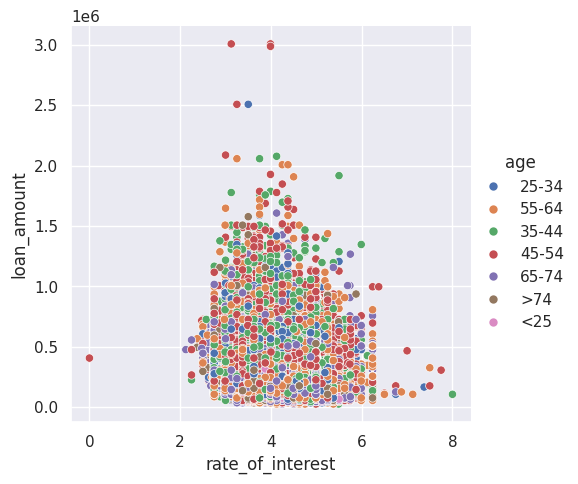

In [ ]:
plt.figure(figsize=(15, 15))
sns.relplot(x ="rate_of_interest", y ="loan_amount", hue='age' ,data = df)

<Axes: xlabel='loan_amount', ylabel='Density'>

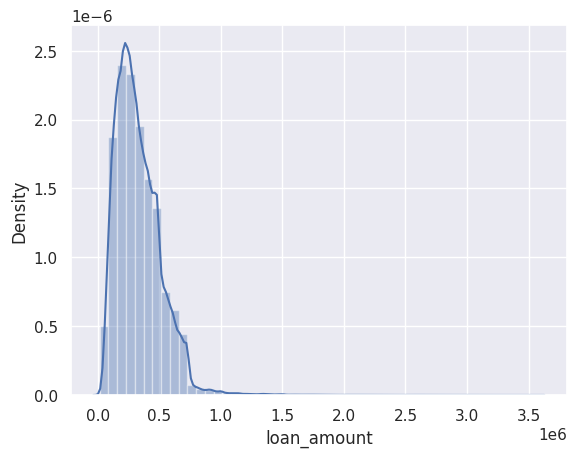

In [ ]:
sns.distplot(df['loan_amount'])

In [ ]:
df["loan_amount"].mean()

np.float64(331117.7439967714)

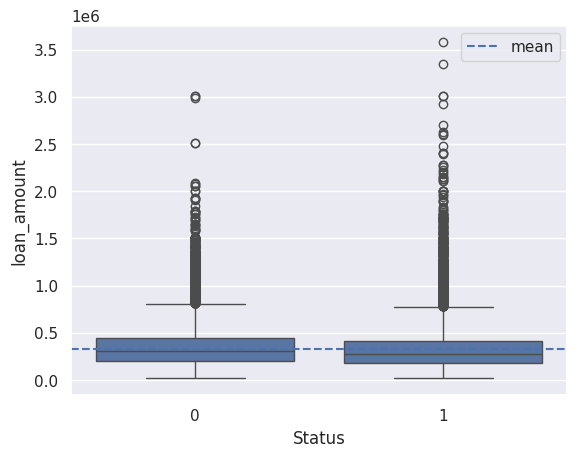

In [ ]:
ax = sns.boxplot(data=df , x='Status' , y ='loan_amount')
ax.axhline(y = df["loan_amount"].mean(), linestyle='--',label = "mean")
plt.legend()
plt.show()

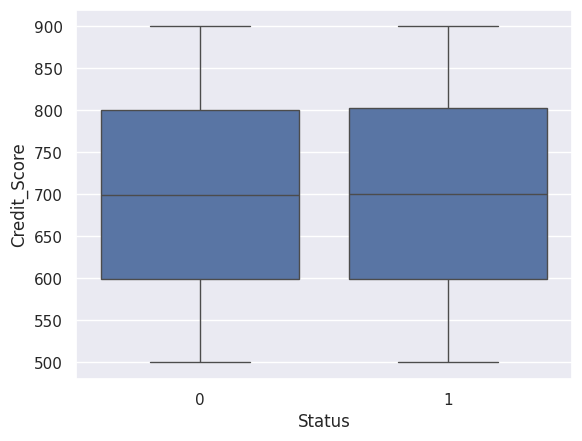

In [ ]:
sns.boxplot(data=df, x='Status', y='Credit_Score')
plt.show()

<Axes: xlabel='Status', ylabel='term'>

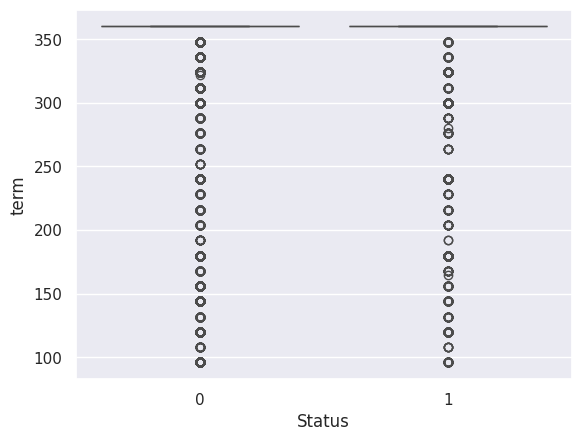

In [ ]:
sns.boxplot(data=df , x='Status' , y ='term')



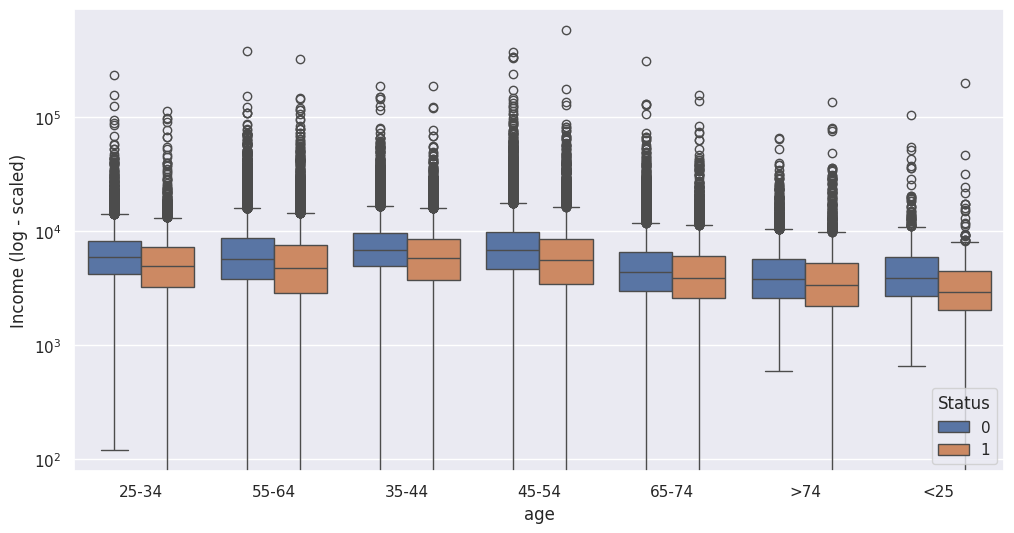

In [ ]:
# using log scale on income axis as the income variable is highly inflated with outliers
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='age',
    y='income',
    hue='Status'
)
plt.ylabel("Income (log - scaled)")
plt.yscale('log')
plt.show()

Status 0 generally has a higher median income than Status 1 within several age groups.

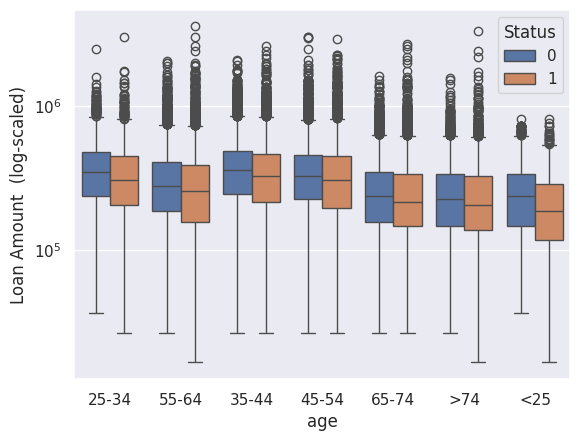

In [ ]:
sns.boxplot(data = df,x = "age",y = "loan_amount",hue = "Status")
plt.ylabel("Loan Amount  (log-scaled)")
plt.yscale("log")
plt.show()

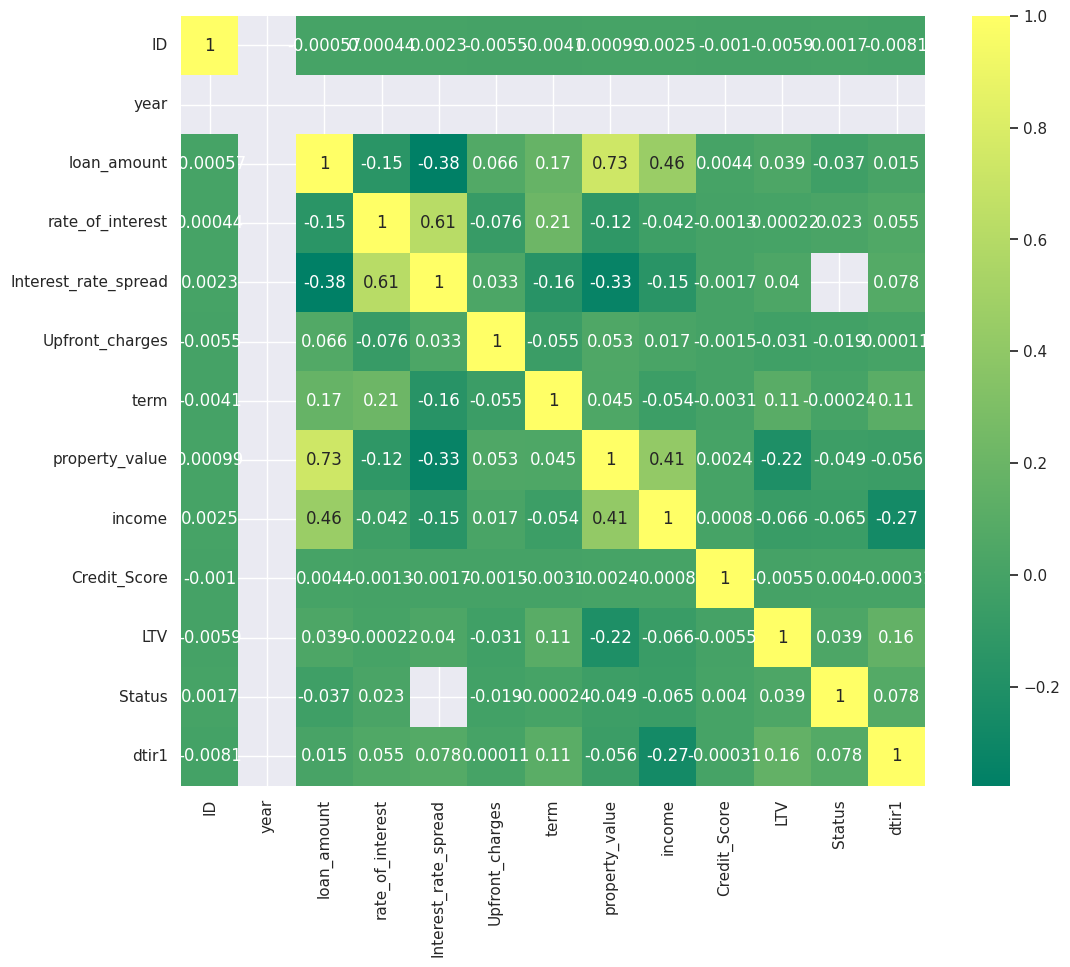

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='summer'
)

plt.show()

In [ ]:
df.groupby('year')['Status'].mean()

,Status
year,
2019,0.246445


since the year column has only one unique value its better to remove it from further analysis

In [ ]:
#droping year and ID
df = df.drop(['year','ID'] , axis = 1)

In [ ]:
df

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.250,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.000,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.125,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.190,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.125,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.500,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


# Pre-Processing

In [ ]:
#checking null values
df.isna().sum()

,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0
loan_amount,0
rate_of_interest,36439


In [ ]:
def missing_values(df):
        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        print ("Dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        return mis_val_table_ren_columns

In [ ]:
# Missing values statistics
miss_values = missing_values(df)
miss_values.head(10)

Dataframe has 32 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Upfront_charges,39642,26.7
Interest_rate_spread,36639,24.6
rate_of_interest,36439,24.5
dtir1,24121,16.2
property_value,15098,10.2
LTV,15098,10.2
income,9150,6.2
loan_limit,3344,2.2
approv_in_adv,908,0.6
submission_of_application,200,0.1


In [ ]:
missing_by_status = df.groupby('Status').apply(
    lambda x: x.isna().mean()
)

print(
    missing_by_status[
        ['Upfront_charges',
         'Interest_rate_spread',
         'rate_of_interest']
    ].T
)

Status                       0         1
Upfront_charges       0.028171  0.995824
Interest_rate_spread  0.000000  1.000000
rate_of_interest      0.000000  0.994541


"The missingness patterns of these variables are almost perfectly associated with the target. This makes the missingness itself highly predictive of Status and raises a serious target-leakage/target-proxy concern. Therefore, these variables were excluded from the predictive modeling."

This implies every single Status = 1 obsvn has missing value of Interest_Rate_Spread,Upfront_charges and rate_of_interest while no Status = 0 observation has it missing.
These feature can be very sensitive to DT algo as this can be used by the algorithm to split the data perfectly i.e. Target variable data leakage may happen

To have reliable concusion of the project we should remove these
 feature from further calculations and analysis

Splitting the data

In [ ]:
X = df.drop(["Status","Interest_rate_spread","Upfront_charges","rate_of_interest"],axis = 1)
y = df["Status"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

"stratify=y ensures that the class proportions in the training and test sets remain approximately the same as in the original dataset."

stratify in train_test_split() is used to preserve the proportion of classes in the training and test sets.

This is important because our target Status is likely imbalanced.

In [ ]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,RobustScaler
# num pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# cat pipeline

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown = 'ignore',drop = 'first'))])

Column Transformer

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

Fitting on Training data

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Status
0    112031
1     36639
Name: count, dtype: int64
Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64


In [ ]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Status
0    75.355653
1    24.644347
Name: proportion, dtype: float64
Status
0    75.354813
1    24.645187
Name: proportion, dtype: float64


This suggests that our data is imbalanced but not extremely imbalanced its moderately imbalanced and can be handled

# Model Building

# KNN

In [ ]:
X_train[0][0],y_train

(np.float64(-0.375),
 141039    0
 121276    0
 11214     1
 129659    0
 13370     0
          ..
 98721     0
 44833     0
 113338    0
 39176     1
 118320    0
 Name: Status, Length: 118936, dtype: int64)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [ ]:
as_knn=accuracy_score(y_test,y_pred)
as_knn

0.8651375529696643

In [ ]:
print(knn.score(X_train,y_train))

0.8750924867155445


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[22129   277]
 [ 3733  3595]]
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.93      0.49      0.64      7328

    accuracy                           0.87     29734
   macro avg       0.89      0.74      0.78     29734
weighted avg       0.87      0.87      0.85     29734



ROC-AUC: 0.8087926842691074


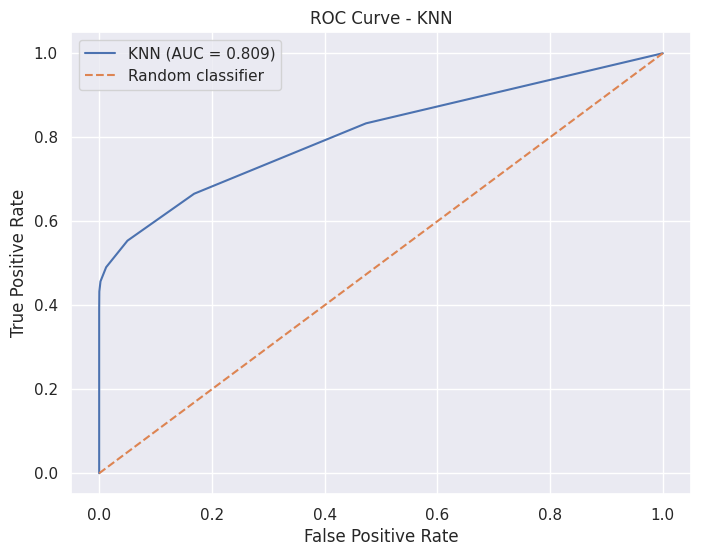

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of Status = 1
y_prob = knn.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_knn = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_knn)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'KNN (AUC = {auc_knn:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

"The KNN model achieved a ROC-AUC of 0.80, indicating strong ability to distinguish between the two classes."

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.8087926842691074)

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.6419642857142858

"The dataset has moderate class imbalance. For models supporting class weighting, class_weight='balanced' was used to give greater importance to the minority class. KNN does not provide a class_weight parameter, so no class weighting was applied to KNN."


# Logistic Regression and Decision trree

In [ ]:
X_train[0][0],y_train

(np.float64(-0.375),
 141039    0
 121276    0
 11214     1
 129659    0
 13370     0
          ..
 98721     0
 44833     0
 113338    0
 39176     1
 118320    0
 Name: Status, Length: 118936, dtype: int64)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
        class_weight='balanced',
        max_iter=50,
        random_state=42
    )

In [ ]:
logistic_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=50, random_state=42)

In [ ]:
y_pred_log = logistic_model.predict(X_test)

In [ ]:
as_log_reg = accuracy_score(y_test,y_pred_log)
print(as_log_reg)

0.8292190758054752


In [ ]:
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[19898  2508]
 [ 2570  4758]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22406
           1       0.65      0.65      0.65      7328

    accuracy                           0.83     29734
   macro avg       0.77      0.77      0.77     29734
weighted avg       0.83      0.83      0.83     29734



ROC-AUC: 0.8391900166030856


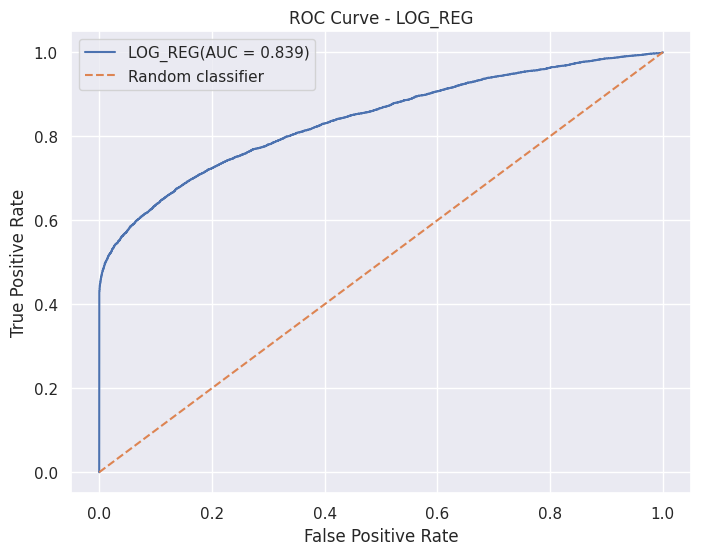

In [ ]:
# Probability of Status = 1
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_log_reg = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_log_reg)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'LOG_REG(AUC = {auc_log_reg:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LOG_REG')
plt.legend()
plt.show()

Decision Tree

In [ ]:
X_train[0][0],y_train

(np.float64(-0.375),
 141039    0
 121276    0
 11214     1
 129659    0
 13370     0
          ..
 98721     0
 44833     0
 113338    0
 39176     1
 118320    0
 Name: Status, Length: 118936, dtype: int64)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[20374  2032]
 [ 2624  4704]]
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     22406
           1       0.70      0.64      0.67      7328

    accuracy                           0.84     29734
   macro avg       0.79      0.78      0.78     29734
weighted avg       0.84      0.84      0.84     29734



Decision Tree ROC-AUC: 0.8277864951907765


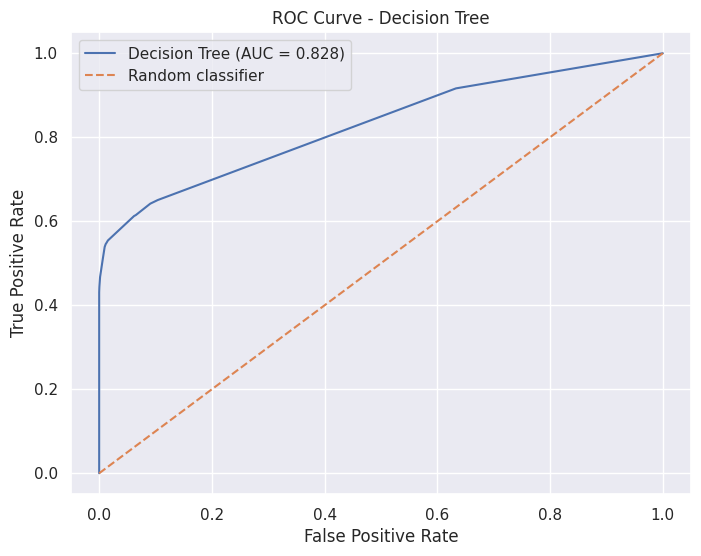

In [ ]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", auc_dt)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

In [ ]:
as_dt = accuracy_score(y_test,y_pred_dt)
print(as_dt)

0.8434115826999394


In [ ]:
y_pred_train = dt.predict(X_train)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    min_samples_leaf=0.01,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8396112194793839


In [ ]:
print(rf.score(X_train,y_train))

0.8372738279410775


Random Forest ROC-AUC: 0.8471512883080289


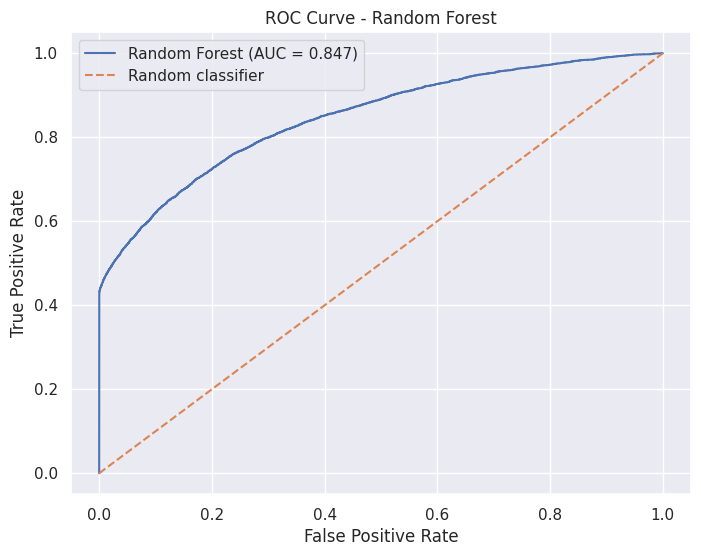

In [ ]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_prob_rf)

np.float64(0.8471512883080289)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[20646  1760]
 [ 3009  4319]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.90     22406
           1       0.71      0.59      0.64      7328

    accuracy                           0.84     29734
   macro avg       0.79      0.76      0.77     29734
weighted avg       0.83      0.84      0.83     29734



In [ ]:
as_rf = accuracy_score(y_test,y_pred)
as_rf

0.8407546915988431

In [ ]:
accuracy_roc_auc = pd.DataFrame({"model" : ["KNN","LOG_REG","DT","RF"],"ROC-AUC_Score" : [auc_knn,auc_log_reg,auc_dt,auc_rf],"Accuracy_Score" : [as_knn,as_log_reg,as_dt,as_rf]})

In [ ]:
accuracy_roc_auc

,model,ROC-AUC_Score,Accuracy_Score
0,KNN,0.806258,0.861236
1,LOG_REG,0.842309,0.831271
2,DT,0.827875,0.856427
3,RF,0.850803,0.840755


# **Metrics Comparison table for KNN,LOG_REG,DT and RF models**

In [ ]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    'KNN': knn,
    'LOG_REG': logistic_model,
    'DT': dt,
    'RF': rf
}

results = []

for name, model in models.items():

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability of class 1
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (1)': precision_score(y_test, y_pred),
        'Recall (1)': recall_score(y_test, y_pred),
        'F1 (1)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df)

     Model  Accuracy  Precision (1)  Recall (1)    F1 (1)   ROC-AUC    PR-AUC
0      KNN  0.861236       0.914552    0.481987  0.631278  0.806258  0.695301
1  LOG_REG  0.831271       0.660064    0.650246  0.655118  0.842309  0.767996
2       DT  0.856427       0.756069    0.616266  0.679047  0.827875  0.726960
3       RF  0.840755       0.704205    0.610126  0.653798  0.850803  0.765852


"Since false negatives are potentially more costly in loan default prediction, I would give greater importance to recall, while also considering precision to ensure that the model does not classify too many genuine borrowers as defaulters."